# NumPy: `*` vs `np.dot` vs `@` (matmul)

These three operations look similar but behave very differently:

---

### `*` — Element-wise (Hadamard) multiplication
Multiplies corresponding elements. Both operands must have the **same shape** (or be broadcastable).

```
A = [[1, 2],    B = [[5, 6],    A * B = [[1·5, 2·6],   = [[ 5, 12],
     [3, 4]]         [7, 8]]            [3·7, 4·8]]       [21, 32]]
```

- Output shape = same as input shape.
- **Not** matrix multiplication.

---

### `np.dot` — Dot product / matrix multiplication (context-dependent)
| Operands | Behavior |
|---|---|
| Two **1-D** arrays | Inner (scalar) product → returns a **scalar** |
| Two **2-D** arrays | Standard **matrix multiplication** (same as `@`) |
| Mixed dimensions | Follows special broadcasting rules (sum-product over last axis of A and second-to-last of B) |

```
a = [1, 2, 3]
b = [4, 5, 6]
np.dot(a, b) = 1·4 + 2·5 + 3·6 = 32   (scalar)
```

---

### `@` / `np.matmul` — Strict matrix multiplication
Always performs **matrix multiplication**. For 2-D arrays it is identical to `np.dot`, but it:
- **Does not** allow scalar operands (unlike `np.dot`).
- Handles stacks of matrices (batched matmul) more consistently than `np.dot`.

```
A = [[1, 2],    B = [[5, 6],    A @ B = [[1·5+2·7, 1·6+2·8],   = [[19, 22],
     [3, 4]]         [7, 8]]             [3·5+4·7, 3·6+4·8]]      [43, 50]]
```

---

### Quick summary table

| Operation | 1-D × 1-D | 2-D × 2-D | Scalar allowed? | Use case |
|---|---|---|---|---|
| `*` | element-wise | element-wise | ✅ | Scaling, masks, Hadamard product |
| `np.dot` | inner product (scalar) | matrix multiply | ✅ | General-purpose, flexible |
| `@` / `np.matmul` | inner product (scalar) | matrix multiply | ❌ | Linear algebra, clarity |

> **Rule of thumb:** Use `@` for matrix multiplication, `*` for element-wise, and `np.dot` only when you specifically need its flexible behavior.

In [13]:
import numpy as np # import numpy for matrix operations

In [14]:
### this function load data from .dat file
def load_dat(filename):
    with open(filename, 'r') as fin:
        lines = fin.readlines()
        dim = len(lines[0].strip().split())
        num_samples = len(lines)
        data = np.zeros((num_samples, dim))
        for i in range(num_samples):
            data[i, :] = np.array([float(x) for x in lines[i].strip().split()])
        return data 

In [15]:
### load data
# call the load_dat function to load X and Y from the corresponding input files
X = load_dat("/home/leandro/Documents/Course_Material/Lab1/code/ex2x.dat")
Y =  load_dat("/home/leandro/Documents/Course_Material/Lab1/code/ex2y.dat")
# get some statistics of the data
num_samples = X.shape[0] # get the first dimension of X (i.e. number of rows)
dim = X.shape[1] # get the second dimension of X (i.e. number of columns)
print('X (%d x %d)' %(num_samples, dim))
print('Y (%d)' %(num_samples))

X (47 x 2)
Y (47)


In [16]:
### add intercept term to all samples in X 
intercept =  np.ones((np.shape(X)[0], 1))
print(np.shape(intercept))
X = np.concat([intercept, X], 1) ### Your code here ###
Y = Y.reshape([-1,1]) 
print('X (%d x %d)' %(num_samples, dim + 1))
print('Y (%d x 1)' %(num_samples))

(47, 1)
X (47 x 3)
Y (47 x 1)


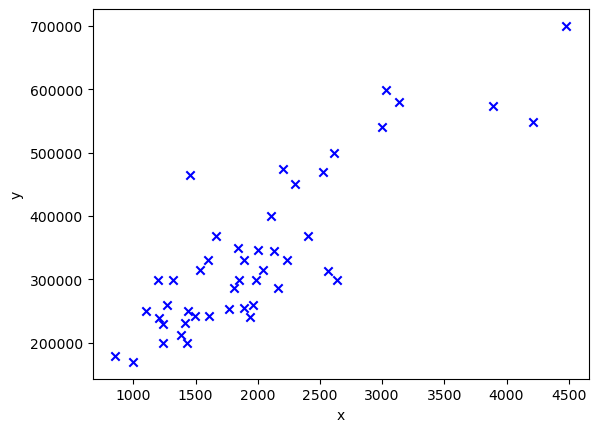

In [21]:
import matplotlib.pyplot as plt
plt.scatter(X[:,1], Y, color='blue', marker='x')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [17]:
### main functions of multivariate linear regression
def pseudo_inverse(A):
    # The pseudo inverse:
    # Input: a matrix A
    # Output: the pseudo_inverse of A
    ### Your code here ###
    # * — Element-wise multiplication
    # p.dot — Dot product (context-dependent)
        # 1-D × 1-D: inner product → scalar
        # 2-D × 2-D: matrix multiplication (same as @)
        # Allows scalar operands
    # @ / np.matmul — Strict matrix multiplication
        # Always performs matrix multiplication. Does not allow scalar operands.
    # Step	Code	                Math	Shape (if A is n×d)
    # 1	    A.T	                    Aᵀ	    d × n
    # 2	    np.dot(A.T, A)	        AᵀA	    d × d
    # 3	    np.linalg.inv(...)      (AᵀA)⁻¹	d × d
    # 4	    np.dot(..., A.T)	    (AᵀA)⁻¹ · Aᵀd × n


    B = np.dot((np.linalg.inv(np.dot(A.T, A))), A.T)
    return B
    
    
def sse(prediction,reference):
    # Calculate the sum of square error between the prediction and reference vectors
    ### Your code here ###
    error = np.sum((prediction - reference)**2)
    return error


In [18]:
### estimate beta
# call the pseudo_inverse to estimate beta from X and Y
beta =  np.dot(pseudo_inverse(X),Y)### Your code here 
# print the estimated (learned) parameters
print(beta)

[[89597.9095428 ]
 [  139.21067402]
 [-8738.01911233]]


In [19]:
### evaluate the model
# calculate the predicted scores
prediction = np.dot(X, beta) ### Your code here
# calculate the sum of square error
error = sse(prediction, Y)
print('Sum of square error: %f' %error)

Sum of square error: 192068324756.665924


In [22]:
### Extra step 
# generate synthetic scores 
Ys = 3 * X[:,0] + 2 * X[:,1] + 0.5 * X[:,2] # generate Ys using a linear function of the features of X
# perform multivariate linear regression with X and Ys as inputs
beta_2 =  pseudo_inverse(X) @ Ys
print('beta_2: ', beta_2)
# calculate the predicted scores
prediction_2 =  np.dot(X, beta_2)
# calculate the sum of square error
error_2 = sse(prediction_2, Ys) 
print('Sum of square error: %f' %error_2) 

beta_2:  [3.  2.  0.5]
Sum of square error: 0.000000
